This Notebook is for tuning the hyperparameters for the P300NN

In [13]:
import mne
import numpy as np
from numpy import matlib as mb
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
from sklearn import metrics
from collections import defaultdict
import regex as re
from sklearn.metrics import accuracy_score
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from sklearn.metrics import roc_auc_score
from models.P300NN import P300NNClassifier
from src.Dataset import Dataset
from src.Speller import Speller
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("CPUs available:", tf.config.list_physical_devices('CPU'))
print("TF use:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "CPU")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
TF use: /device:GPU:0


I0000 00:00:1777098510.246665 1706991 gpu_device.cc:2043] Created device /device:GPU:0 with 9615 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5
I0000 00:00:1777098510.252940 1706991 gpu_device.cc:2043] Created device /device:GPU:0 with 9615 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5


Divide and Separate Training and Testing Paths

In [14]:
def group_paths_by_participant(data_paths):
    participant_files = defaultdict(lambda: {'train': [], 'test': []})
    for path in data_paths:
        parts = path.split(os.sep)
        participant_id = parts[6]

        if 'Train' in path or 'train' in path:
            participant_files[participant_id]['train'].append(path)
        elif 'Test' in path or 'test' in path:
            participant_files[participant_id]['test'].append(path)
        else:
            print(f"Unclassified path: {path}")

    return participant_files


In [15]:
important_channels = ['EEG_Fz', 'EEG_Cz', 'EEG_Pz', 'EEG_P3',
                      'EEG_PO7', 'EEG_PO8', 'EEG_P4', 'EEG_Oz']

#first using default values
ds = Dataset(
    glob_path=os.path.join(project_root, "data", "*", "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8, 
)

participant_files = group_paths_by_participant(ds.data_paths)
participants = list(participant_files.keys())

 BASELINE
Processing participant L_01 for trial Baseline
Epoch 1/3000


I0000 00:00:1777098513.786372 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1632525__.48
I0000 00:00:1777098517.151172 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1632525__.48


119/119 - 8s - 71ms/step - accuracy: 0.2661 - loss: 0.6998
Epoch 2/3000
119/119 - 4s - 32ms/step - accuracy: 0.8228 - loss: 0.6945
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.6328 - loss: 0.6936
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.3196 - loss: 0.6946
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.8159 - loss: 0.6939
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.1683 - loss: 0.6939
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.5291 - loss: 0.6944
Epoch 8/3000
119/119 - 1s - 5ms/step - accuracy: 0.4725 - loss: 0.6939
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Processing participant L_02 for trial Baseline
Epoch 1/3000


I0000 00:00:1777098534.133479 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1641743__.48
I0000 00:00:1777098537.490980 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1641743__.48


119/119 - 8s - 71ms/step - accuracy: 0.5386 - loss: 0.6994
Epoch 2/3000
119/119 - 4s - 32ms/step - accuracy: 0.4233 - loss: 0.6947
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.4746 - loss: 0.6943
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.3862 - loss: 0.6936
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.6931 - loss: 0.6940
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.3074 - loss: 0.6940
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.7683 - loss: 0.6941
Epoch 8/3000
119/119 - 1s - 6ms/step - accuracy: 0.6444 - loss: 0.6933
Epoch 9/3000
119/119 - 1s - 5ms/step - accuracy: 0.4529 - loss: 0.6945
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.3937 - loss: 0.6942
Epoch 11/3000
119/119 - 1s - 5ms/step - accuracy: 0.4873 - loss: 0.6939
Epoch 12/3000
119/119 - 1s - 5ms/step - accuracy: 0.5413 - loss: 0.6943
Epoch 13/3000
119/119 - 1s - 5ms/step - accuracy: 0.4460 - loss: 0.6938
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Processing participant L_03 for trial Basel

...

119/119 - 8s - 71ms/step - accuracy: 0.5132 - loss: 0.6928
Epoch 2/3000
119/119 - 4s - 32ms/step - accuracy: 0.5259 - loss: 0.6904
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.6013 - loss: 0.6664
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.6474 - loss: 0.6482
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.6323 - loss: 0.6410
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.6627 - loss: 0.6287
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.6947 - loss: 0.6072
Epoch 8/3000
119/119 - 1s - 5ms/step - accuracy: 0.6611 - loss: 0.6034
Epoch 9/3000
119/119 - 1s - 5ms/step - accuracy: 0.6775 - loss: 0.5981
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.6733 - loss: 0.6022
Epoch 11/3000
119/119 - 1s - 5ms/step - accuracy: 0.6862 - loss: 0.6066
Epoch 12/3000
119/119 - 1s - 5ms/step - accuracy: 0.6966 - loss: 0.5805
Epoch 13/3000
119/119 - 1s - 5ms/step - accuracy: 0.6974 - loss: 0.5720
Epoch 14/3000
119/119 - 1s - 5ms/step - accuracy: 0.7153 - loss: 0.5712
Epoch 15/300

I0000 00:00:1777099362.739614 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2097049__.48
I0000 00:00:1777099366.118996 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2097049__.48


119/119 - 8s - 71ms/step - accuracy: 0.2923 - loss: 0.6938
Epoch 2/3000
119/119 - 4s - 32ms/step - accuracy: 0.4000 - loss: 0.6944
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.6778 - loss: 0.6935
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.6749 - loss: 0.6934
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.5495 - loss: 0.6933
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.6442 - loss: 0.6931
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.5725 - loss: 0.6933
Epoch 8/3000
119/119 - 1s - 5ms/step - accuracy: 0.6407 - loss: 0.6937
Epoch 9/3000
119/119 - 1s - 5ms/step - accuracy: 0.4492 - loss: 0.6932
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.4823 - loss: 0.6933
Epoch 11/3000
119/119 - 1s - 5ms/step - accuracy: 0.2048 - loss: 0.6933
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Processing participant L_11 for trial LessLearningRate
Epoch 1/3000


I0000 00:00:1777099384.932346 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2107836__.48
I0000 00:00:1777099388.350067 1707145 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2107836__.48


119/119 - 9s - 72ms/step - accuracy: 0.5087 - loss: 0.6938
Epoch 2/3000
119/119 - 4s - 31ms/step - accuracy: 0.4992 - loss: 0.6844
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.5804 - loss: 0.6501
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.6241 - loss: 0.6311
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.6437 - loss: 0.6246
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.6503 - loss: 0.6129
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.6513 - loss: 0.6104
Epoch 8/3000
119/119 - 1s - 5ms/step - accuracy: 0.6653 - loss: 0.5981
Epoch 9/3000
119/119 - 1s - 5ms/step - accuracy: 0.6709 - loss: 0.5902
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.6905 - loss: 0.5855
Epoch 11/3000
119/119 - 1s - 5ms/step - accuracy: 0.6862 - loss: 0.5824
Epoch 12/3000
119/119 - 1s - 5ms/step - accuracy: 0.6854 - loss: 0.5829
Epoch 13/3000
119/119 - 1s - 6ms/step - accuracy: 0.7008 - loss: 0.5741
Epoch 14/3000
119/119 - 1s - 5ms/step - accuracy: 0.6860 - loss: 0.5742
Epoch 15/300

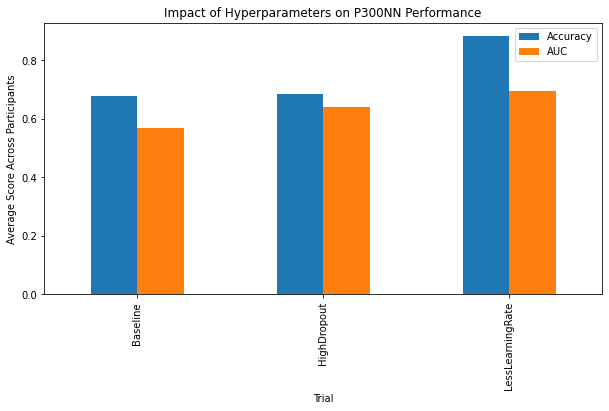

In [16]:
trials = [
    {"name": "Baseline", "lr": 0.01, "dropout": 0.3, "F1": 16},
    {"name": "HighDropout", "lr": 0.01, "dropout": 0.5, "F1": 16},
    {"name": "LessLearningRate", "lr": 0.001, "dropout": 0.3, "F1": 16},
]

trial_res = []

for t in trials:
    print(f" {t['name'].upper()}")
    
    for participant_id in list(participant_files.keys()): 
        print(f"Processing participant {participant_id} for trial {t['name']}")

        train_files = participant_files[participant_id]['train']
        test_files = participant_files[participant_id]['test']

        X_train, y_train, X_test, y_test = [], [], [], []

        # Load data
        for path in train_files:
            ds = Dataset(path, important_channels=important_channels, sample_rate=256, 
                         tmin=0, tmax=0.8, use_car=True, notch_filter=True)
            X, y = ds[0]
            X_train.append(X)
            y_train.append(y)

        for path in test_files:
            ds = Dataset(path, important_channels=important_channels, sample_rate=256, 
                         tmin=0, tmax=0.8, use_car=True, notch_filter=True)
            X, y = ds[0]
            X_test.append(X)
            y_test.append(y)

        X_train = np.vstack(X_train)[..., np.newaxis]
        y_train = np.concatenate(y_train)
        X_test = np.vstack(X_test)[..., np.newaxis]
        y_test = np.concatenate(y_test)

        # Train with hyperparameters 
        clf = P300NNClassifier(
            learning_rate=t['lr'],
            dropout_rate=t['dropout'],
            F1=t['F1'],
            optim_type='adam' #as identified in the OptimizerSelection Notebook
        )
        clf.train(X_train, y_train)

        # Evaluate
        probs = clf.model.predict(X_test)
        y_pred = np.argmax(probs, axis=1)
        scores = probs[:, 1] - probs[:, 0]
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, scores)

        trial_res.append({
            "Trial": t['name'],
            "Participant": participant_id,
            "Accuracy": acc,
            "AUC": auc,
            "LR": t['lr'],
            "Dropout": t['dropout']
        })

# Analysis
comparison_df = pd.DataFrame(trial_res)
trial_summary = comparison_df.groupby("Trial")[["Accuracy", "AUC"]].mean()

print("\nHyperparameter Trial Summary")
print(trial_summary)

trial_summary.plot(kind='bar', figsize=(10, 5))
plt.title("Impact of Hyperparameters on P300NN Performance")
plt.ylabel("Average Score Across Participants")
plt.show()

Three hyperparameter configurations, Baseline, HighDropout, and LessLearningRate, were compared on the P300 neural network across Accuracy and AUC metrics. LessLearningRate clearly outperformed the others, achieving the highest accuracy and AUC, suggesting that a slower learning rate allows the model to converge better. HighDropout very slightly improved accuracy and AUC over the baseline showing that it doesn't have much impact. Overall, reducing the learning rate appears to be the most impactful hyperparameter adjustment for this model because it allows slower convergence and allows the model to learn the pattern of the data better. 